# Iris Dataset - Exploratory Data Analysis & Classification


## Objective
The objective of this task is to understand how to load, inspect, summarize, and visualize a dataset using Python libraries such as Pandas, Matplotlib, and Seaborn.

## Business Context

Although the Iris dataset is a classical dataset, this analysis simulates a real-world classification problem where the goal is to distinguish categories based on measurable features.

Such analysis can be applied in:
- Agriculture (plant classification)
- Quality control systems
- Automated decision-making pipelines


## Dataset Description

The Iris dataset is a well-known dataset in machine learning and statistics. It contains 150 records of iris flowers belonging to three species:

- Setosa
- Versicolor
- Virginica

### Features:
- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

### Target Variable:
- Species (categorical)

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [37]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Insight:
The dataset contains 150 observations with 4 numerical features and 1 categorical target variable (species).

In [38]:
print("Shape:", df.shape)
print("Columns:", df.columns)
df.info()
df.describe()

Shape: (150, 5)
Columns: Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Insight:
All features are numerical and there are no missing values, indicating a clean dataset suitable for analysis.

In [39]:
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
Duplicates: 1


## Exploratory Data Analysis (EDA)

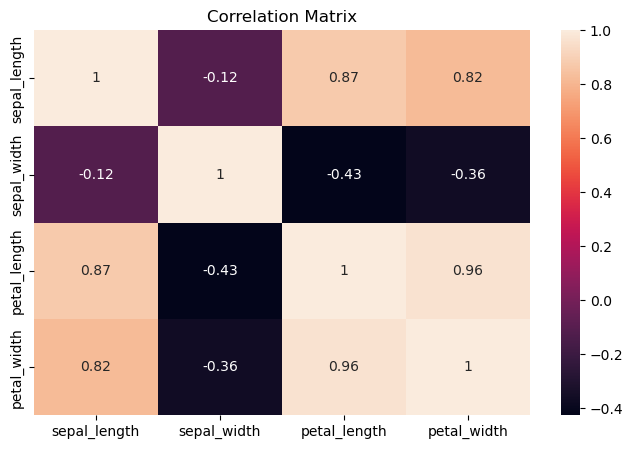

In [25]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

### Insight:
Petal length and petal width show a strong positive correlation, suggesting they are key features for classification.

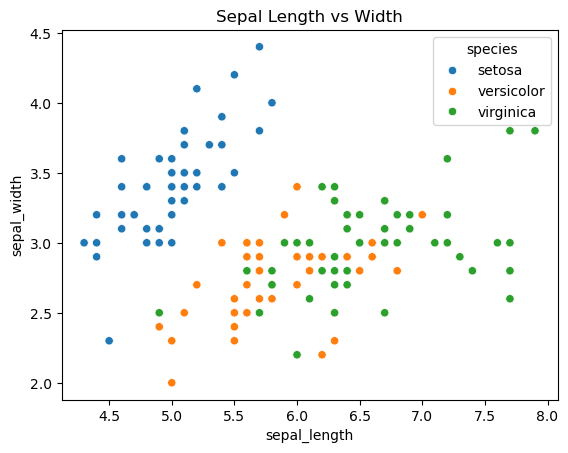

In [26]:
sns.scatterplot(data=df, x='sepal_length', y='sepal_width', hue='species')
plt.title("Sepal Length vs Width")
plt.show()

### Insight:
Sepal features show overlapping clusters, meaning they are less effective in distinguishing species.

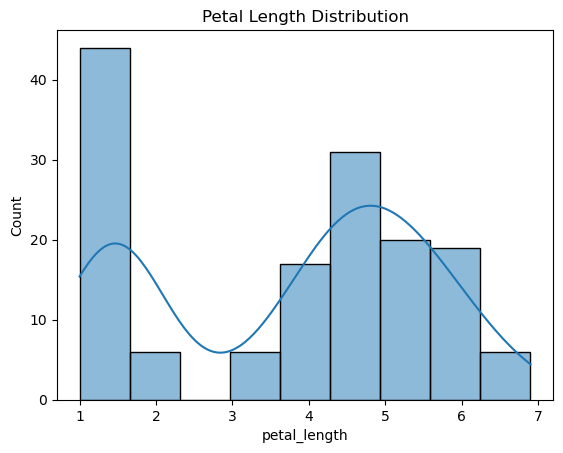

In [27]:
sns.histplot(df['petal_length'], kde=True)
plt.title("Petal Length Distribution")
plt.show()

### Insight:
The distribution of petal length shows clear separation, indicating its importance in classification.

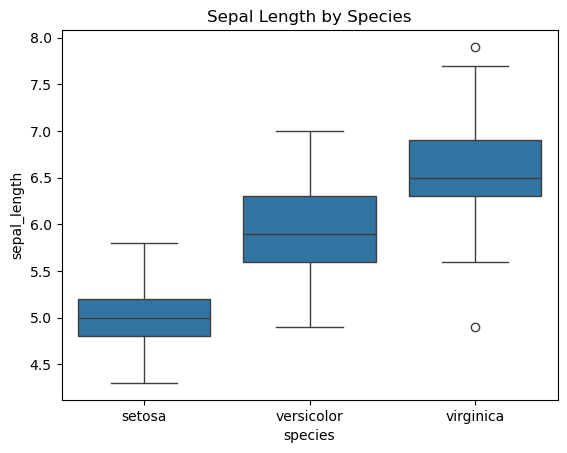

In [28]:
sns.boxplot(data=df, x='species', y='sepal_length')
plt.title("Sepal Length by Species")
plt.show()

### Insight:
Some overlap exists in sepal length across species, reinforcing that it is a weaker predictor.

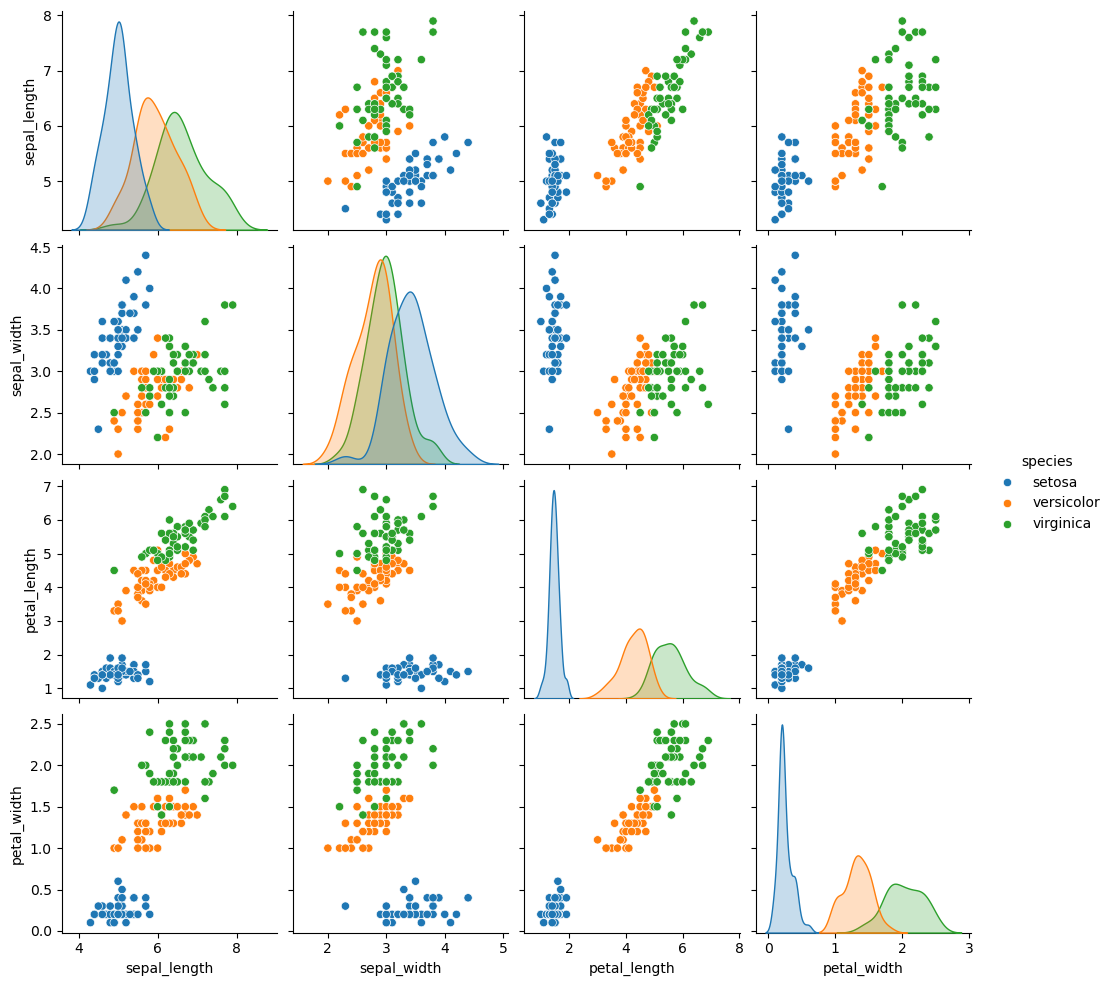

In [30]:
sns.pairplot(df, hue='species')
plt.show()

### Insight:
Petal-related features clearly separate species, while sepal features show overlap. This confirms earlier observations.

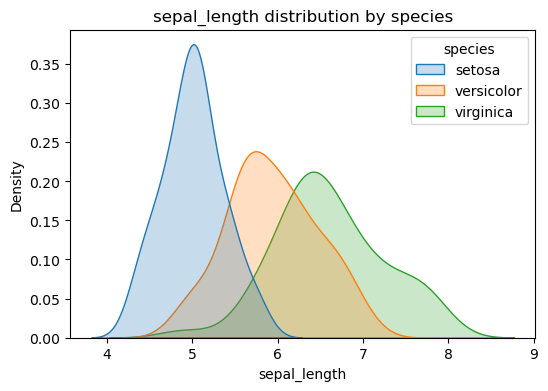

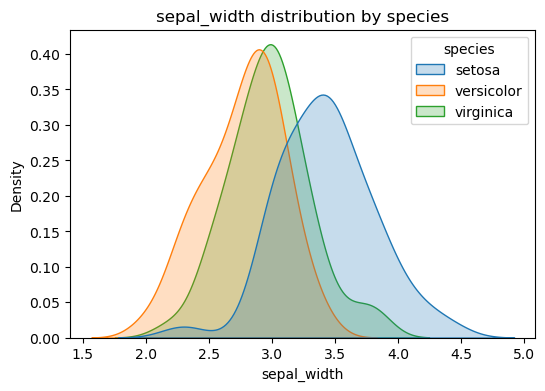

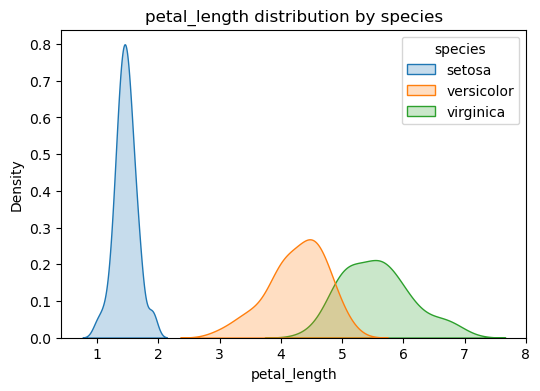

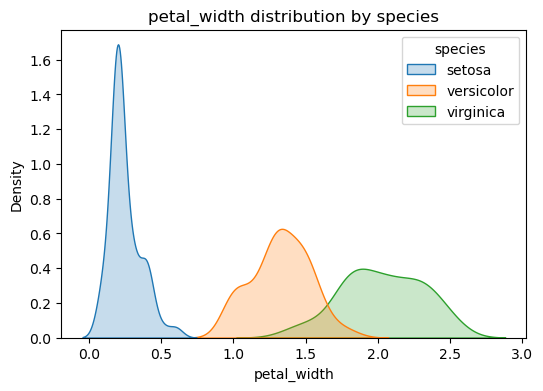

In [31]:
for col in df.columns[:-1]:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x=col, hue='species', fill=True)
    plt.title(f"{col} distribution by species")
    plt.show()

## Model Training & Testing

In [32]:
X = df.drop('species', axis=1)
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

### Insight:
Random Forest is used because it handles non-linear relationships and provides feature importance.

In [33]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### Insight:
The model achieves high accuracy, indicating strong separability of the dataset.

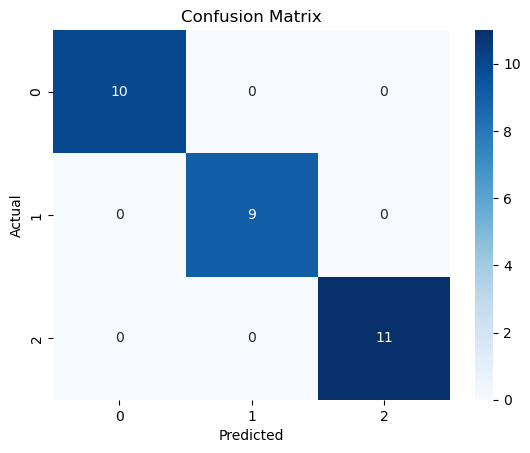

In [34]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Insight:
Most predictions are correct, with minor confusion between similar species (Versicolor and Virginica).

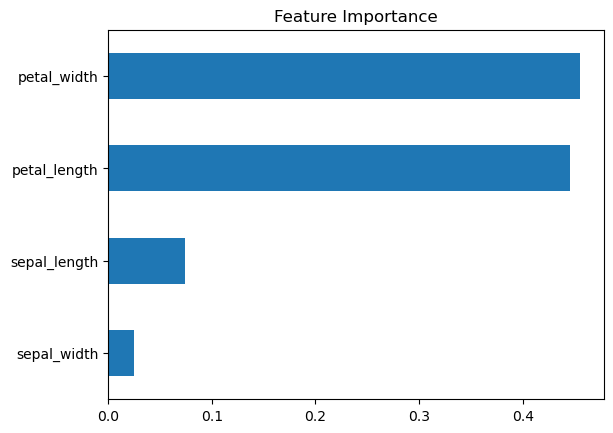

In [35]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

### Insight:
Petal length is the most important feature, confirming EDA findings.

In [36]:
scores = cross_val_score(model, X, y, cv=5)
print("Cross-validation accuracy:", scores.mean())

Cross-validation accuracy: 0.96


### Insight:
Consistent cross-validation accuracy shows that the model is stable and not overfitting.

## Conclusion

- The dataset is clean with no missing values.
-  Petal features are the strongest predictors
- Strong correlation exists between petal length and petal width.
- Scatter plots show clear separation between species.
- Random Forest model achieved high accuracy.
## Key Insights

- Petal length and petal width are the most significant features for classification.
- Sepal dimensions show overlap between species, making them less reliable predictors.
- The dataset is highly structured, leading to strong model performance.
- Minimal overlap between classes suggests low classification ambiguity.
- Petal-based measurements are critical for distinguishing species.
## Limitations

- Dataset is small (150 samples)
- Real-world data may contain noise and missing values
- Model may not generalize to more complex datasets
## Recommendations

- Future models should prioritize petal-based features.
- Dimensionality reduction techniques (e.g., PCA) could further optimize performance.
- Similar approaches can be applied to other biological classification problems.